# Predictive Paradox — Electricity Demand Forecasting.

In [1]:
# STEP 1 - Import Libraries
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# utility
import warnings
warnings.filterwarnings("ignore")

In [2]:
# STEP 2 - Load Data Files
power = pd.read_excel("PGCB_date_power_demand.xlsx")
weather = pd.read_excel("weather_data.xlsx")
eco = pd.read_csv("economic_full_1.csv")

In [3]:
# STEP 3 - Check Data Loaded or Not
print(power.head())
print(weather.head())
print(eco.head())

             datetime  generation_mw  demand_mw  load_shedding   gas  \
0 2015-04-19 22:00:00         6323.0       6323              0     0   
1 2015-04-19 21:00:00         6667.0       6667              0     0   
2 2015-04-19 19:00:00         6897.0       6897              0  4415   
3 2015-04-19 18:30:00         6933.0       6933              0  4423   
4 2015-04-19 18:00:00         6874.0       6874              0  4319   

   liquid_fuel  coal  hydro  solar  wind  india_bheramara_hvdc  india_tripura  \
0            0     0      0    NaN   NaN                     0              0   
1            0     0      0    NaN   NaN                     0              0   
2         1836   161     41    NaN   NaN                   444              0   
3         1862   159     45    NaN   NaN                   444              0   
4         1892   155     65    NaN   NaN                   443              0   

   india_adani  nepal       remarks  
0          NaN    NaN           NaN  
1   

In [4]:
# STEP 4 — Check Columns
print(power.columns)
print(weather.columns)
print(eco.columns)

Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks'],
      dtype='str')
Index(['latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone',
       'timezone_abbreviation', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9'],
      dtype='str')
Index(['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961',
       '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979',
       '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2

In [5]:
# STEP 5 - Check data information and missing values

print("POWER DATASET")
print(power.info())
print()
print(power.isnull().sum())

print("\n" + "="*50 + "\n")

print("WEATHER DATASET")
print(weather.info())
print()
print(weather.isnull().sum())

print("\n" + "="*50 + "\n")

print("ECONOMIC DATASET")
print(eco.info())
print()
print(eco.isnull().sum())

POWER DATASET
<class 'pandas.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[us]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal        

In [6]:
# STEP 6 - Remove duplicate rows

power = power.drop_duplicates()
weather = weather.drop_duplicates()
eco = eco.drop_duplicates()

print("Duplicates removed successfully")
print("Power Shape :", power.shape)
print("Weather Shape :", weather.shape)
print("Economic Shape :", eco.shape)

Duplicates removed successfully
Power Shape : (92490, 15)
Weather Shape : (107307, 10)
Economic Shape : (1516, 69)


In [7]:
# STEP 7 - Convert date columns into datetime format

power.iloc[:, 0] = pd.to_datetime(power.iloc[:, 0], errors="coerce")
weather.iloc[:, 0] = pd.to_datetime(weather.iloc[:, 0], errors="coerce")

print("Date columns converted successfully")
print()

print("Power Data Types")
print(power.dtypes)

print()
print("Weather Data Types")
print(weather.dtypes)

Date columns converted successfully

Power Data Types
datetime                datetime64[us]
generation_mw                  float64
demand_mw                        int64
load_shedding                    int64
gas                              int64
liquid_fuel                      int64
coal                             int64
hydro                            int64
solar                          float64
wind                           float64
india_bheramara_hvdc             int64
india_tripura                    int64
india_adani                    float64
nepal                          float64
remarks                            str
dtype: object

Weather Data Types
latitude                 object
longitude                object
elevation                object
utc_offset_seconds       object
timezone                 object
timezone_abbreviation    object
Unnamed: 6               object
Unnamed: 7               object
Unnamed: 8               object
Unnamed: 9               object
dtype: 

In [8]:
# STEP 8 - Remove rows where date is missing and sort data by date

power = power.dropna(subset=[power.columns[0]])
weather = weather.dropna(subset=[weather.columns[0]])

power = power.sort_values(by=power.columns[0]).reset_index(drop=True)
weather = weather.sort_values(by=weather.columns[0]).reset_index(drop=True)

print("Rows with missing date removed")
print("Data sorted by date successfully")

print()
print("Power Shape :", power.shape)
print("Weather Shape :", weather.shape)

Rows with missing date removed
Data sorted by date successfully

Power Shape : (92490, 15)
Weather Shape : (107305, 10)


In [9]:
# STEP 9 - Fill missing values in numeric columns

power = power.fillna(power.median(numeric_only=True))
weather = weather.fillna(weather.median(numeric_only=True))
eco = eco.fillna(eco.median(numeric_only=True))

print("Missing numeric values filled successfully")

print()
print("Power Missing Values")
print(power.isnull().sum())

print()
print("Weather Missing Values")
print(weather.isnull().sum())

print()
print("Economic Missing Values")
print(eco.isnull().sum())

Missing numeric values filled successfully

Power Missing Values
datetime                    0
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                       0
wind                        0
india_bheramara_hvdc        0
india_tripura               0
india_adani                 0
nepal                       0
remarks                 86103
dtype: int64

Weather Missing Values
latitude                 0
longitude                0
elevation                0
utc_offset_seconds       0
timezone                 0
timezone_abbreviation    0
Unnamed: 6               1
Unnamed: 7               1
Unnamed: 8               1
Unnamed: 9               1
dtype: int64

Economic Missing Values
Country Name      0
Indicator Name    0
Indicator Code    0
1960              0
1961              0
                 ..
2021              0


In [11]:
# STEP 10 - Rename first column as date for easy use

power = power.rename(columns={power.columns[0]: "date"})
weather = weather.rename(columns={weather.columns[0]: "date"})

print("Column names updated successfully")

print()
print("Power Columns")
print(power.columns)

print()
print("Weather Columns")
print(weather.columns)

Column names updated successfully

Power Columns
Index(['date', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks'],
      dtype='str')

Weather Columns
Index(['date', 'longitude', 'elevation', 'utc_offset_seconds', 'timezone',
       'timezone_abbreviation', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9'],
      dtype='str')


In [12]:
# STEP 11 FIX - Convert both date columns to same datetime format, then merge

power["date"] = pd.to_datetime(power["date"], errors="coerce")
weather["date"] = pd.to_datetime(weather["date"], errors="coerce")

# remove rows where date became invalid
power = power.dropna(subset=["date"])
weather = weather.dropna(subset=["date"])

# merge datasets
data = pd.merge(power, weather, on="date", how="left")

print("Power and Weather data merged successfully")

print()
print("Final Shape :", data.shape)

print()
print(data.head())

Power and Weather data merged successfully

Final Shape : (92490, 24)

                 date  generation_mw  demand_mw  load_shedding  gas  \
0 2015-04-19 00:00:00         4821.0       4821              0    0   
1 2015-04-19 01:00:00         3612.0       3612              0    0   
2 2015-04-19 02:00:00         3727.0       3727              0    0   
3 2015-04-19 03:00:00         3632.0       3632              0    0   
4 2015-04-19 04:00:00         3641.0       3641              0    0   

   liquid_fuel  coal  hydro  solar  wind  ...  remarks  longitude  elevation  \
0            0     0      0    0.0   4.0  ...      NaN       25.7         87   
1            0     0      0    0.0   4.0  ...      NaN       25.3         88   
2            0     0      0    0.0   4.0  ...      NaN       24.9         90   
3            0     0      0    0.0   4.0  ...      NaN         25         90   
4            0     0      0    0.0   4.0  ...      NaN       25.2         91   

   utc_offset_seconds

In [13]:
# STEP 12 - Create year column and merge economic data

data["year"] = data["date"].dt.year

# make sure first column of eco is year
eco = eco.rename(columns={eco.columns[0]: "year"})

# convert year column into number
eco["year"] = pd.to_numeric(eco["year"], errors="coerce")

# remove wrong year rows
eco = eco.dropna(subset=["year"])
eco["year"] = eco["year"].astype(int)

# merge economic data
data = pd.merge(data, eco, on="year", how="left")

print("Economic data merged successfully")

print()
print("Final Shape :", data.shape)

print()
print(data.head())

Economic data merged successfully

Final Shape : (92490, 93)

                 date  generation_mw  demand_mw  load_shedding  gas  \
0 2015-04-19 00:00:00         4821.0       4821              0    0   
1 2015-04-19 01:00:00         3612.0       3612              0    0   
2 2015-04-19 02:00:00         3727.0       3727              0    0   
3 2015-04-19 03:00:00         3632.0       3632              0    0   
4 2015-04-19 04:00:00         3641.0       3641              0    0   

   liquid_fuel  coal  hydro  solar  wind  ...  2016  2017  2018  2019 2020  \
0            0     0      0    0.0   4.0  ...   NaN   NaN   NaN   NaN  NaN   
1            0     0      0    0.0   4.0  ...   NaN   NaN   NaN   NaN  NaN   
2            0     0      0    0.0   4.0  ...   NaN   NaN   NaN   NaN  NaN   
3            0     0      0    0.0   4.0  ...   NaN   NaN   NaN   NaN  NaN   
4            0     0      0    0.0   4.0  ...   NaN   NaN   NaN   NaN  NaN   

  2021 2022 2023 2024 2025  
0  NaN  NaN  

In [14]:
# STEP 13 - Create time based features from date column

data["hour"] = data["date"].dt.hour
data["day"] = data["date"].dt.day
data["month"] = data["date"].dt.month
data["day_of_week"] = data["date"].dt.dayofweek
data["week"] = data["date"].dt.isocalendar().week.astype(int)

# weekend flag
data["is_weekend"] = data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

print("Time features created successfully")

print()
print(data[["date", "hour", "day", "month", "day_of_week", "week", "is_weekend"]].head())

Time features created successfully

                 date  hour  day  month  day_of_week  week  is_weekend
0 2015-04-19 00:00:00     0   19      4            6    16           1
1 2015-04-19 01:00:00     1   19      4            6    16           1
2 2015-04-19 02:00:00     2   19      4            6    16           1
3 2015-04-19 03:00:00     3   19      4            6    16           1
4 2015-04-19 04:00:00     4   19      4            6    16           1


In [15]:
# STEP 14 - Find demand column and create lag features

# check your real demand column name first
print("Columns in data:")
print(data.columns)

# change this name if needed
demand_col = "demand_mw"

# lag features
data["lag_1"] = data[demand_col].shift(1)
data["lag_2"] = data[demand_col].shift(2)
data["lag_3"] = data[demand_col].shift(3)
data["lag_24"] = data[demand_col].shift(24)

print("Lag features created successfully")

print()
print(data[[demand_col, "lag_1", "lag_2", "lag_3", "lag_24"]].head(30))

Columns in data:
Index(['date', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'longitude',
       'elevation', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'year',
       'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963',
       '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972',
       '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
       '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024', 

In [16]:
# STEP 15 - Create rolling mean features

# change demand_col name if your target column is different
demand_col = "demand_mw"

# rolling average features using past values
data["roll_mean_3"] = data[demand_col].shift(1).rolling(3).mean()
data["roll_mean_6"] = data[demand_col].shift(1).rolling(6).mean()
data["roll_mean_24"] = data[demand_col].shift(1).rolling(24).mean()

print("Rolling mean features created successfully")

print()
print(data[[demand_col, "roll_mean_3", "roll_mean_6", "roll_mean_24"]].head(30))

Rolling mean features created successfully

    demand_mw  roll_mean_3  roll_mean_6  roll_mean_24
0        4821          NaN          NaN           NaN
1        3612          NaN          NaN           NaN
2        3727          NaN          NaN           NaN
3        3632  4053.333333          NaN           NaN
4        3641  3657.000000          NaN           NaN
5        3283  3666.666667          NaN           NaN
6        3444  3518.666667  3786.000000           NaN
7        3592  3456.000000  3556.500000           NaN
8        4049  3439.666667  3553.166667           NaN
9        4488  3695.000000  3606.833333           NaN
10       4803  4043.000000  3749.500000           NaN
11       5029  4446.666667  3943.166667           NaN
12       5284  4773.333333  4234.166667           NaN
13       5157  5038.666667  4540.833333           NaN
14       5692  5156.666667  4801.666667           NaN
15       5651  5377.666667  5075.500000           NaN
16       5604  5500.000000  5269.33333

In [17]:
# STEP 16 - Create target column for next hour demand

# change demand_col name if needed
demand_col = "demand_mw"

# target = next hour demand
data["target"] = data[demand_col].shift(-1)

print("Target column created successfully")

print()
print(data[[demand_col, "target"]].head(10))

Target column created successfully

   demand_mw  target
0       4821  3612.0
1       3612  3727.0
2       3727  3632.0
3       3632  3641.0
4       3641  3283.0
5       3283  3444.0
6       3444  3592.0
7       3592  4049.0
8       4049  4488.0
9       4488  4803.0


In [18]:
# STEP 17 - Remove rows with missing values created by lag/rolling/target

data = data.dropna().reset_index(drop=True)

print("Rows with missing values removed successfully")

print()
print("Final Shape :", data.shape)

print()
print(data.head())

Rows with missing values removed successfully

Final Shape : (0, 107)

Empty DataFrame
Columns: [date, generation_mw, demand_mw, load_shedding, gas, liquid_fuel, coal, hydro, solar, wind, india_bheramara_hvdc, india_tripura, india_adani, nepal, remarks, longitude, elevation, utc_offset_seconds, timezone, timezone_abbreviation, Unnamed: 6, Unnamed: 7, Unnamed: 8, Unnamed: 9, year, Indicator Name, Indicator Code, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, hour, day, month, day_of_week, week, is_weekend, lag_1, ...]
Index: []

[0 rows x 107 columns]


In [19]:
# STEP 18 - Prepare features (X) and target (y)

# columns not used for training
remove_cols = ["date", "target"]

# if any text/object columns exist, remove them too
for col in data.columns:
    if data[col].dtype == "object" and col not in remove_cols:
        remove_cols.append(col)

# create X and y
X = data.drop(columns=remove_cols)
y = data["target"]

print("Features and target created successfully")

print()
print("X Shape :", X.shape)
print("y Shape :", y.shape)

print()
print("Feature Columns:")
print(X.columns)

Features and target created successfully

X Shape : (0, 96)
y Shape : (0,)

Feature Columns:
Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'year',
       'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963',
       '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972',
       '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
       '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'hour',
       'day', 'month', 'day_of_week', 'week', 'is_weekend', 'lag_1', 'l

In [20]:
# STEP 19 - Create chronological train and test data

# use 80% rows for training and 20% rows for testing
split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train and Test data created successfully")

print()
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print()
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

Train and Test data created successfully

X_train Shape : (0, 96)
X_test Shape  : (0, 96)

y_train Shape : (0,)
y_test Shape  : (0,)


In [21]:
# STEP 20 - Model train

# 1. Merge power + weather again
data = pd.merge(power, weather, on="date", how="left")


# 2. Create year and merge economic data

data["year"] = data["date"].dt.year

eco = eco.rename(columns={eco.columns[0]: "year"})
eco["year"] = pd.to_numeric(eco["year"], errors="coerce")
eco = eco.dropna(subset=["year"])
eco["year"] = eco["year"].astype(int)

data = pd.merge(data, eco, on="year", how="left")


# 3. Choose target demand column

print("Available Columns:")
print(data.columns)

# change if needed
demand_col = "demand_mw"


# 4. Create features

data["hour"] = data["date"].dt.hour
data["day"] = data["date"].dt.day
data["month"] = data["date"].dt.month
data["dayofweek"] = data["date"].dt.dayofweek

# lag features
data["lag_1"] = data[demand_col].shift(1)
data["lag_24"] = data[demand_col].shift(24)

# target
data["target"] = data[demand_col].shift(-1)


# 5. Fill missing values (DON'T delete all rows)

data = data.replace([np.inf, -np.inf], np.nan)
data = data.ffill().bfill()

# remove only last target null row
data = data.dropna(subset=["target"]).reset_index(drop=True)

print("Rows after rebuild :", len(data))


# 6. Prepare X and y

X = data.drop(columns=["date", "target"], errors="ignore")
y = data["target"]

# convert text columns
X = pd.get_dummies(X, drop_first=True)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

# 7. Safe split

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

# 8. Train model

model = RandomForestRegressor(
    n_estimators=10,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print()
print("Model trained successfully")

Available Columns:
Index(['date', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks', 'longitude',
       'elevation', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'year',
       'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963',
       '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972',
       '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981',
       '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990',
       '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999',
       '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008',
       '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020', '2021', '2022', '2023', '2024'

In [22]:
# STEP 21 - Predict values using trained model

pred = model.predict(X_test)

print("Prediction completed successfully")
print()
print("First 10 Predictions:")
print(pred[:10])

Prediction completed successfully

First 10 Predictions:
[13652.56698203 13838.24661457 13975.32448036 13975.32448036
 13217.46322221 14500.08177388 14374.31167775 11827.51902454
 14374.31167775 13975.32448036]


In [23]:
# STEP 22 - Calculate MAPE accuracy score

mape = mean_absolute_percentage_error(y_test, pred) * 100

print("Model Evaluation Completed")
print()
print("MAPE Score :", round(mape, 2), "%")

Model Evaluation Completed

MAPE Score : 4.34 %


In [24]:
# STEP 23 - Compare actual vs predicted values

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
})

print("Comparison Table")
print()
print(result.head(10))

Comparison Table

    Actual     Predicted
0  13900.0  13652.566982
1  14000.0  13838.246615
2  14100.0  13975.324480
3  14300.0  13975.324480
4  14500.0  13217.463222
5  14350.0  14500.081774
6  14300.0  14374.311678
7  14300.0  11827.519025
8  14000.0  14374.311678
9  13600.0  13975.324480


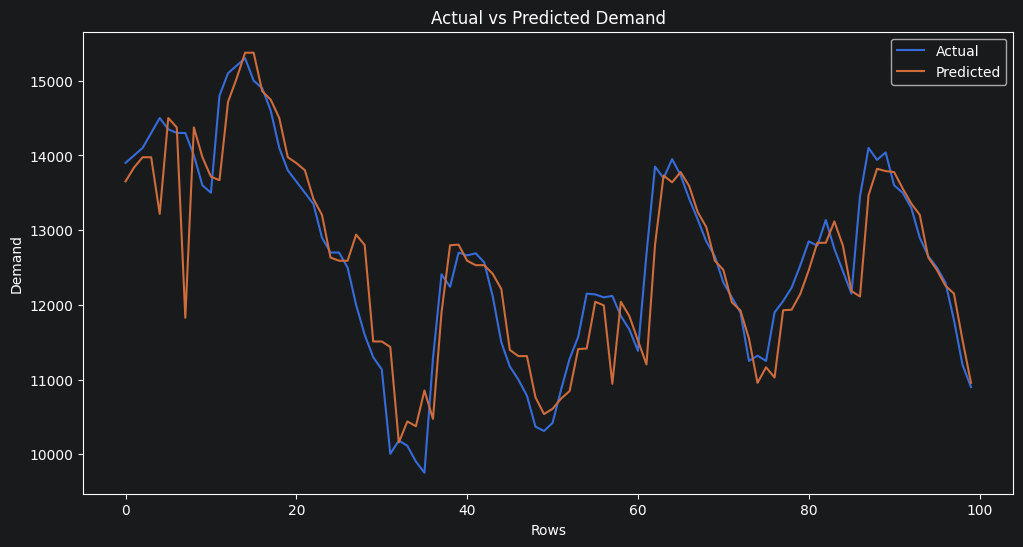

In [25]:
# STEP 24 - Plot Actual vs Predicted graph

plt.figure(figsize=(12,6))

plt.plot(result["Actual"].values[:100], label="Actual")
plt.plot(result["Predicted"].values[:100], label="Predicted")

plt.title("Actual vs Predicted Demand")
plt.xlabel("Rows")
plt.ylabel("Demand")
plt.legend()

plt.show()

In [26]:
# STEP 25 - Feature importance of model

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("Top Important Features")
print()
print(importance.head(10))

Top Important Features

                         Feature  Importance
1                      demand_mw    0.629384
0                  generation_mw    0.249993
5403          Unnamed: 9_1612.01    0.031819
4655          Unnamed: 9_1206.85    0.031087
85                        lag_24    0.009812
80                          hour    0.005686
304               longitude_30.6    0.004630
4                    liquid_fuel    0.004018
1255  timezone_abbreviation_24.9    0.003566
767      utc_offset_seconds_34.8    0.003432


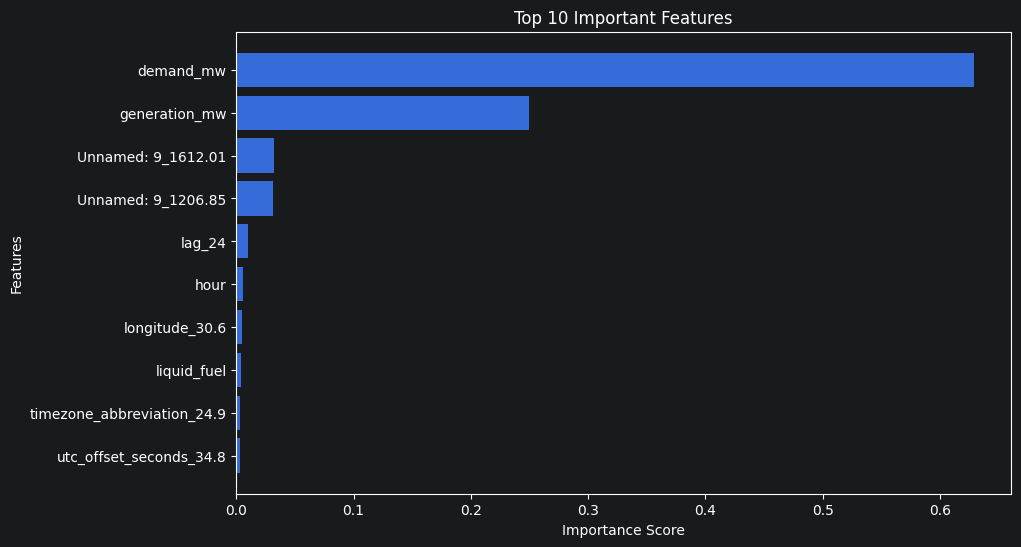

In [27]:
# STEP 26 - Plot top feature importance graph

top_features = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [28]:
# STEP 27 - Save prediction result into CSV file

result.to_csv("prediction_result.csv", index=False)

print("File saved successfully")
print("Saved file name : prediction_result.csv")

File saved successfully
Saved file name : prediction_result.csv
